**Introduction:** Customer churn prediction is a crucial application of data analytics in the banking sector. It focuses on identifying customers who are likely to discontinue using a bank's services or switch to competitors. Customer retention is often more cost-effective than acquiring new customers, making churn prediction valuable for improving profitability and maintaining long-term customer relationships. By analyzing customer behavior, transaction history, demographics and service usage patterns, predictive models can help banks detect early signs of churn and take proactive measures such as personalized offers, improved services and targeted retention strategies.

**Problem Statement:** Banks face significant challenges in retaining customers due to increasing competition, changing customer expectations and the availability of alternative financial services. Losing customers can lead to reduced revenue and higher acquisition costs. The problem is to develop a customer churn prediction model that can analyze historical customer data and accurately identify customers who are at risk of leaving the bank. The goal is to support decision-making by enabling the bank to implement timely retention strategies, reduce churn rates and improve customer satisfaction.

In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np

#Upload CSV file from computer
from google.colab import files

uploaded = files.upload()
#Click "Choose Files" and upload Churn Modelling CSV

#Read the dataset
df = pd.read_csv("Churn_Modelling.csv")

#Display first 5 rows
print("First 5 rows of the Dataset:")
print(df.head())

Saving Churn_Modelling.csv to Churn_Modelling.csv
First 5 rows of the Dataset:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58   

**Data understanding and description:** This is an essential step in customer churn prediction as it involves exploring, analyzing and interpreting the dataset to identify patterns, relationships and factors that may influence customer attrition. In this project, the bank customer dataset contains information about customers' demographic details, account characteristics and banking activities which can be used to predict whether a customer is likely to leave the bank.

The dataset typically includes following types of features:

**1. Customer Demographic Information:** This includes personal details of customers such as:

Customer ID: Unique identifier for each customer

Age: Customer's age which may influence churn behavior

Gender: Male or female customer information

Geography: Customer's location or country

These features help to understand how churn may vary accross different customer groups.

**2. Account Information:** This category describes customer's relationship with the bank such as:

Tenure: Number of years the customer has been with bank

Balance: Amount of money in the customer's account

Number of Products: Banking products used by the customer (eg: savings account, credit card, loan)

Credit Score: Customer's financial reliability indicator

These attributes help to analyze customer loyalty and engagement with the bank.

**3. Customer Activity and Service Usage:** These variables show customer interaction and behavior, including:

Has Credit Card: Whether the customer owns a credit card

Is Active Member: Indicates whether the customer actively uses banking services

Estimated Salary: Customer's income level

These features may provide important signals related to churn risk.

**4. Target Variable Exited (Churn):** The target variable indicating whether a customer has left the bank (1=Yes, 0=No).

This variable is used to train the prediction model.

In [ ]:
#Shape of dataset
print(df.shape)

#Column Information
print(df.columns)

#Data types and missing values
print(df.info())

(10000, 14)
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  Estima

**Data cleaning and preparation:** This is a critical step in building an accurate customer churn prediction model. Raw data often contains inconsistencies, missing values, duplicate records and irrelevant information that can negatively affect model performance. This stage ensures the dataset is accurate, complete and ready for analysis and machine learning.

**1. Handling Missing Values**: The first step in data cleaning is checking for missing or null values in the dataset. Missing values can be handled by:

Removing records with excessive missing data

Filling missing numerical values using mean or median

Replacing missing categorical values with mode or appropriate labels

This helps maintain data quality and prevents errors during model training.

**2. Removing Duplicates and Irrelevant Data:** Duplicate customer records and unnecessary columns such as Customer ID, Row Number or Surname may not contribute to churn prediction and can be removed. Eliminating irrelevant features reduces complexity and improves model efficiency.

**3. Handling Categorical Data:** Some variables such as Gender and Geography are categorical and need to be converted into numerical format for machine learning models. This can be done using:

Label Encoding

One-Hot Encoding

This transformation allows algorithms to process categorical information effectively.

In [ ]:
#Check Missing Values
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
#Check total duplicate rows in dataset
duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

#Display duplicate records
df[df.duplicated()]

Total duplicate rows: 0


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [ ]:
#Check number of unique values in each column
print("Unique values per column")
print(df.nunique())

Unique values per column
RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64


In [ ]:
#Drop Irrelevant Columns
#These columns do not contribute to churn prediction:
# RowNumber   -> Just record index
# CustomerId  -> Unique customer identifier
# Surname     -> Customer names are not useful for prediction

df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

#Verify remaining columns after dropping
print("Updated Columns:")
print(df.columns)

Updated Columns:
Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [ ]:
#Encode Categorical Variables
#Convert categorical columns (Geography and Gender) into numerical format using One-Hot Encoding

#drop_first=True avoids dummy variable trap
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

#Display updated dataset structure
print("Encoded Columns:")
print(df.columns)

#Preview first 5 rows after encoding
print("\nUpdated Dataset Preview:")
print(df.head())

Encoded Columns:
Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

Updated Dataset Preview:
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1              False   
1               1        112542.58       0              False   
2               0        113931.57       1              False   
3               0         93826.63       0              False   
4   

**Exploratory Data Analysis:** It is performed to understand the distribution of the target variable Churn, and identify any class imbalance in the dataset. A bar chart was used to visualize the number of customers who stayed versus those who left the bank. This analysis helps reveal patterns in the data and is important for preparing the dataset before building a customer churn prediction model.

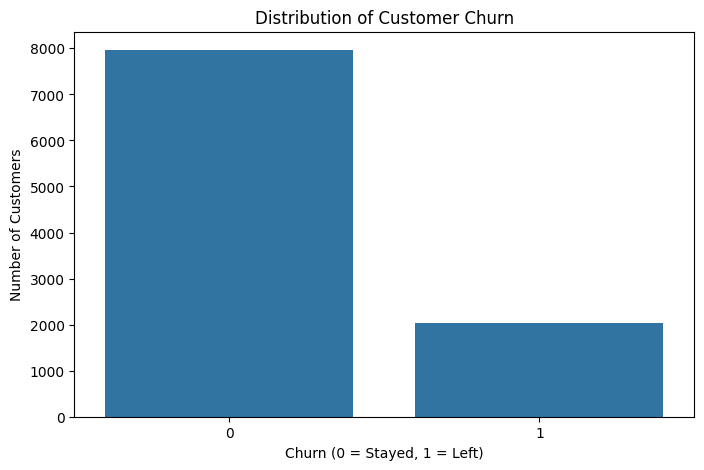

In [3]:
#Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns


#Churn Distribution Analysis

#This bar chart shows the number of customers who stayed (0)
#versus customers who left the bank (1).
#It helps identify class imbalance in the target variable.

#Set figure size for better readability
plt.figure(figsize=(8,5))

#Create count plot (bar chart) for Churn column
sns.countplot(x='Exited', data=df)

#Add title and axis labels
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Customers')

#Display the plot
plt.show()

**Model Training and Testing:** A **Decision Tree** Classifier was used to train the customer churn prediction model. The dataset was divided into training and testing sets, where the model was trained on the training data and evaluated on unseen test data. The model predicts whether a customer is likely to churn or remain, and its performance was measured using accuracy.

In [6]:
#Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Ensure df is in the correct preprocessed state for X and Y
# Drop Irrelevant Columns
df_processed = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Encode Categorical Variables
df_processed = pd.get_dummies(df_processed, columns=['Geography', 'Gender'], drop_first=True)

#Split data into features and target
#X contains input features
X = df_processed.drop('Exited', axis=1)

#Y contains target variable
Y = df_processed['Exited']

#Split dataset into training and testing sets
#80% for training and 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
#Train Decision Tree Classification Model
#Create Decision Tree model
model = DecisionTreeClassifier(random_state=42)

#Train model using training data
model.fit(X_train, y_train)

#Test the model
#Make predictions on test data
y_pred = model.predict(X_test)

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display model accuracy
print("Decision Tree Model Accuracy:", accuracy)

Decision Tree Model Accuracy: 0.7805


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Feature Scaling
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

#Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

#Train Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

#Predictions
y_pred = log_model.predict(X_test_scaled)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy (scaled):", accuracy)

Logistic Regression Accuracy (scaled): 0.811


After training and evaluating both models, **Logistic Regression** achieved a higher accuracy **(81.10%)** compared to **Decision Tree (78.05%)**. This indicates that Logistic Regression performs better on this dataset for predicting customer churn. Feature scaling further improved the performance of Logistic Regression by ensuring all features contributed equally to the model.

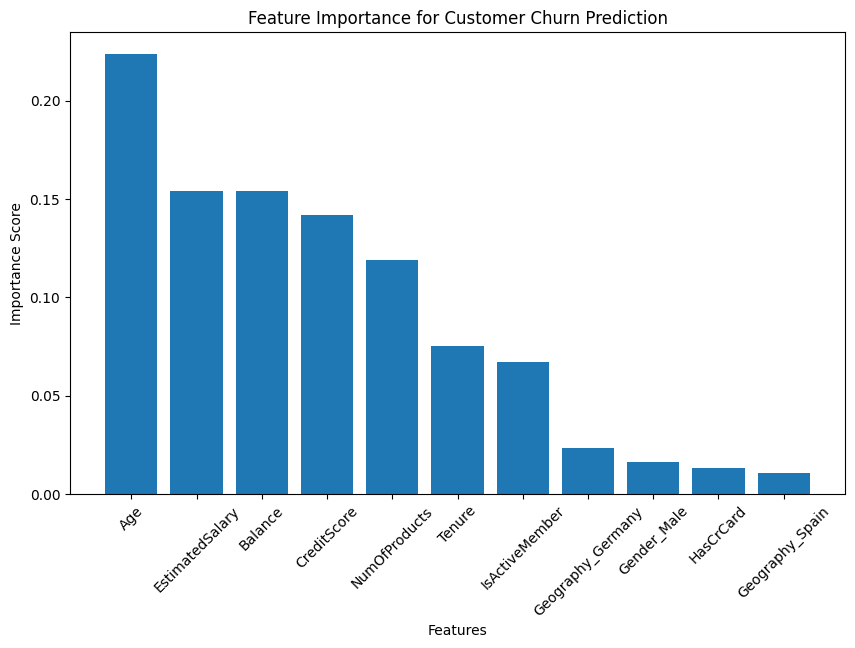

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

#Get feature importance from Decision Tree
#Model = already trained DecisionTreeClassifier

feature_importance = model.feature_importances_

#Create a DataFrame for better understanding
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

#Sort features by importance (highest first)
features_df = features_df.sort_values(by='Importance', ascending=False)

#Plot feature importance
plt.figure(figsize=(10,6))
plt.bar(features_df['Feature'], features_df['Importance'])

plt.title('Feature Importance for Customer Churn Prediction')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.show()

**Feature Importance Analysis:** It was analyzed using the Decision Tree model to understand which variables have the most influence on customer churn. The results show that features with higher importance scores contribute more significantly to predicting whether a customer will leave or stay. This helps in identifying key factors driving churn behavior and supports better decision-making for customer retention strategies.

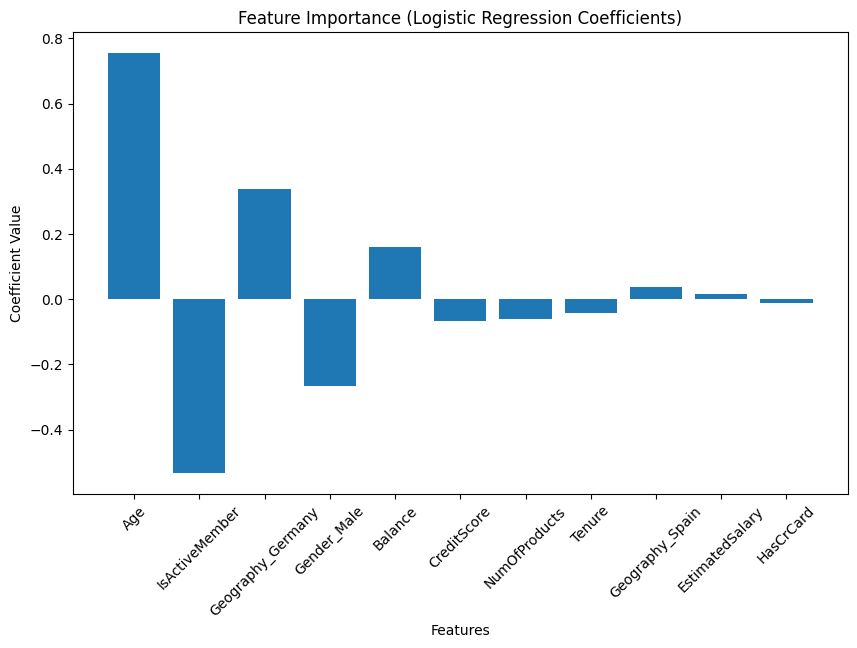

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

#Get feature importance from Logistic Regression
#log_model = already trained Logistic Regression model

# Coefficients represent feature impact on prediction
feature_importance = log_model.coef_[0]

#Create DataFrame for better understanding
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': feature_importance
})

#Sort by absolute value (strongest impact first)
features_df['Absolute_Coefficient'] = features_df['Coefficient'].abs()
features_df = features_df.sort_values(by='Absolute_Coefficient', ascending=False)

#Plot feature importance
plt.figure(figsize=(10,6))
plt.bar(features_df['Feature'], features_df['Coefficient'])

plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.show()

In **Logistic Regression**, feature importance is determined using model coefficients. Each coefficient represents the impact of a feature on predicting customer churn. Positive values indicate an increase in churn probability, while negative values indicate a decrease. This helps in understanding which factors most strongly influence customer churn behavior.

**Conclusion:** In this project, customer churn was analyzed using **Exploratory Data Analysis** and two **classification models**: **Logistic Regression** and **Decision Tree**. The results showed that **Logistic Regression** performed better with an accuracy of **81.10%** compared to **Decision Tree’s 78.05%**. Feature importance analysis revealed that certain factors had a stronger influence on customer churn prediction. Overall, the study highlights that Logistic Regression is more suitable for this dataset and that key features play an important role in identifying customers likely to leave.